### Importando librerias

In [ ]:
import numpy as np
import geopandas as gpd
import rasterio as rs
import matplotlib.pyplot as plt
import pprint
from IPython.display import Image

### Rasterize faults | Rasterizar fallas

###### We use the "gdal:rasterize" tool (Rasterize (vector to raster)) in QGIS
###### Hacemos uso de la herramienta "gdal:rasterize" (Rasterizar (vectorial a ráster)) en QGIS

In [ ]:
processing.run("gdal:rasterize", {'INPUT':'data/vector/faults.gpkg|layername=Fallas',
                                  'FIELD':'Numero','BURN':0,'UNITS':1,'WIDTH':30,'HEIGHT':30,'EXTENT':'698145.821200000,729861.380100000,5220787.102700000,5262463.866100000 [EPSG:32718]',
                                  'NODATA':0,'OPTIONS':'','DATA_TYPE':5,'INIT':None,'INVERT':False,'EXTRA':'',
                                  'OUTPUT':'data/processed/faults_rasterized.tif'})

### Calculate distance to faults | Calcular distancia a fallas

###### We use the "gdal:proximity" tool (Proximity (raster distance)) in QGIS
###### Hacemos uso de la herramienta "gdal:proximity" (Proximidad (distancia ráster)) en QGIS

In [ ]:
processing.run("gdal:proximity", {'INPUT':'data/processed/faults_rasterized.tif',
                                  'BAND':1,'VALUES':'','UNITS':0,'MAX_DISTANCE':0,'REPLACE':0,'NODATA':0,'OPTIONS':'','EXTRA':'','DATA_TYPE':5,
                                  'OUTPUT':'data/processed/faults_distance.tif'})

### Reclassify fault distance | Reclasificar distancia a fallas

###### We use the "grass7:r.reclass" tool (r.reclass) in QGIS
###### Hacemos uso de la herramienta "grass7:r.reclass" (r.reclass) en QGIS

In [ ]:
processing.run("grass7:r.reclass", {'input':'data/processed/faults_distance.tif',
                                    'rules':'','txtrules':'0 thru 500=4\n500.01 thru 1000=3\n1000.01 thru 2000=2\n2000.01 thru 1000000=1',
                                    'output':'data/processed/faults_distance_reclass.tif',
                                    'GRASS_REGION_PARAMETER':None,'GRASS_REGION_CELLSIZE_PARAMETER':0,'GRASS_RASTER_FORMAT_OPT':'','GRASS_RASTER_FORMAT_META':''})

### Reclassify geological environment | Reclasificar ambiente geológico

In [ ]:
#Read a GeoPackage (.gpkg) file | leer un archivo en formato Geopackage (.gpkg)
data=gpd.read_file("data/vector/geology.gpkg")

In [ ]:
#Inspect columns | Inspeccionar columnas
data.columns

Index(['AREA', 'PERIMETER', 'GEOLOGIA_', 'GEOLOGIA_I', 'INT_ORIG', 'LAYER',
       'CD_CORRELA', 'CD_GEOL', 'UNIDAD', 'RANGO', 'EDAD_MAX', 'EDAD_MIN',
       'CRON_MAX', 'CRON_MIN', 'GEOMORFOLO', 'ROCA1', 'PROP_ROC1', 'ROCA2',
       'PROP_ROC2', 'ROCA3', 'PROP_ROC3', 'ROCA4', 'PROP_ROC4', 'AMBIENTE',
       'LEYENDA', 'Clase', 'geometry'],
      dtype='object')

In [ ]:
#Valores únicos en la columna "AMBIENTE"
data["AMBIENTE"].unique()  

array(['Plutonico', 'Volcanico', 'Otros', 'Sedimentario continental',
       'Metamorfico', 'Sedimentario marino'], dtype=object)

##### Create numerical values column | Creando columna de valores numericos 

In [ ]:
#Creando una nueva lista vacia.
clase=[] 
#Asignacion de valores segun la columna "AMBIENTE".
for i in data["AMBIENTE"]:   
    if i == "Sedimentario continental" or i == "Sedimentario marino" or i== "Otros":
        clase.append(1)
    elif i== "Plutonico":
        clase.append(2)
    elif i== "Volcanico":
        clase.append(3)
    elif i == "Metamorfico":
        clase.append(4)
#Agregando una nueva columna llamada "Clase" al DataFrame.
data["Clase"]=clase
#Guardano el DataFrame. 
data.to_file(r"C:\Users\bruta\Documents\maletin\UACH\septimo semestre\SIG\practico 8\Geologia.gpkg",driver="GPKG") 

In [ ]:
#Inspect attribute table | Inspeccionando la tabla de atributos
data

,AREA,PERIMETER,GEOLOGIA_,GEOLOGIA_I,INT_ORIG,LAYER,CD_CORRELA,CD_GEOL,UNIDAD,RANGO,...,ROCA2,PROP_ROC2,ROCA3,PROP_ROC3,ROCA4,PROP_ROC4,AMBIENTE,LEYENDA,Clase,geometry
0,3.157678e+09,2365931.000,11555,12313,GEO-11627,GEOLOGIA,M61,Kig,NaN,Batholith,...,granodiorita,principal,tonalita,principal,NaN,NaN,Plutonico,C:/LEYENDAS/LEYM61.htm#Kig,2,"MULTIPOLYGON (((719192.436 5261167.062, 719912..."
1,1.028118e+08,135574.900,11961,12323,GEO-12051,GEOLOGIA,M61,Q3i,Estratovolcanes y complejos volcanicos,Informal unit,...,andesita basaltica,principal,dacita,principal,NaN,NaN,Volcanico,C:/LEYENDAS/LEYM61.htm#Q3i,3,"MULTIPOLYGON (((709636.479 5261848.088, 710007..."
2,1.780518e+07,32899.850,12025,13387,Null-102,GEOLOGIA,M61,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Otros,C:/SinInformacion.htm,1,"MULTIPOLYGON (((723248.450 5260878.002, 724617..."
3,7.053011e+06,14273.410,12036,12961,GEO-12127,GEOLOGIA,M61,Pl3,Secuencias lavicas y centros volcanicos basico...,Informal unit,...,andesita basaltica,principal,NaN,NaN,NaN,NaN,Volcanico,C:/LEYENDAS/LEYM61.htm#Pl3,3,"MULTIPOLYGON (((711433.866 5261719.994, 714500..."
4,1.035112e+07,26472.610,12038,12983,GEO-12129,GEOLOGIA,M61,Pl3,Secuencias lavicas y centros volcanicos basico...,Informal unit,...,andesita basaltica,principal,NaN,NaN,NaN,NaN,Volcanico,C:/LEYENDAS/LEYM61.htm#Pl3,3,"MULTIPOLYGON (((701654.870 5262416.915, 702196..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60,1.897242e+06,12415.710,12170,12280,GEO-12272,GEOLOGIA,M61,Q1,"Depositos aluviales, coluviales y de remocion ...",Informal unit,...,deposito glacifluvial,secundaria,deposito deltaico,secundaria,deposito litoral,secundaria,Sedimentario continental,C:/LEYENDAS/LEYM61.htm#Q1,1,"MULTIPOLYGON (((714906.358 5223356.942, 714690..."
61,4.161267e+07,35456.840,12173,12299,GEO-12275,GEOLOGIA,M61,PzTr4(b),NaN,Complex,...,anfibolita,principal,ultramafica,ocasional,NaN,NaN,Metamorfico,C:/LEYENDAS/LEYM61.htm#PzTr4(,4,"MULTIPOLYGON (((712150.282 5221854.275, 707216..."
62,2.512369e+06,7467.549,12176,12887,GEO-12278,GEOLOGIA,M61,Mg,NaN,Batholith,...,diorita,principal,tonalita,principal,NaN,NaN,Plutonico,C:/LEYENDAS/LEYM61.htm#Mg,2,"MULTIPOLYGON (((703245.756 5225174.338, 703109..."
63,2.340559e+06,17705.160,12182,12889,GEO-12284,GEOLOGIA,M61,Q3i,Estratovolcanes y complejos volcanicos,Informal unit,...,andesita basaltica,principal,dacita,principal,NaN,NaN,Volcanico,C:/LEYENDAS/LEYM61.htm#Q3i,3,"MULTIPOLYGON (((707216.269 5222208.277, 707045..."


### Rasterize geology | Rasterizar geología

###### We use the "gdal:rasterize" tool (Rasterize (vector to raster)) in QGIS
###### Hacemos uso de la herramienta "gdal:rasterize" (Rasterizar (vectorial a ráster)) en Qgis

In [ ]:
processing.run("gdal:rasterize", {'INPUT':'data/vector/geology.gpkg|layername=Geologia',
                                  'FIELD':'Clase','BURN':0,'UNITS':1,'WIDTH':30,'HEIGHT':30,'EXTENT':'698145.821200000,729861.380100000,5220787.102700000,5262463.866100000 [EPSG:32718]',
                                  'NODATA':0,'OPTIONS':'','DATA_TYPE':5,'INIT':None,'INVERT':False,'EXTRA':'',
                                  'OUTPUT':'data/raster/geology_rasterized.tif'})

### Generate slope raster | Generar raster de pendiente

###### We use the "native:slope" tool (Slope) in QGIS
###### Hacemos uso de la herramienta "native:slope" (Pendiente) en Qgis.

In [ ]:
processing.run("native:slope", {'INPUT':'data/raster/srtm_18s_30m.tif',
                                'Z_FACTOR':1,'OUTPUT':'data/processed/slope.tif'})

### Reclassify slope | Reclasificar pendiente

###### We use the "grass7:r.reclass" tool (r.reclass) in QGIS
###### Hacemos uso de la herramienta "grass7:r.reclass" (r.reclass)” en Qgis

In [ ]:
processing.run("grass7:r.reclass", {'input':'data/processed/slope.tif',
                                    'rules':'','txtrules':'0 thru 5=1\n5.1 thru 10=2\n10.1 thru 20=3\n20.1 thru 90=4',
                                    'output':'data/processed/slope_classified.tif',
                                    'GRASS_REGION_PARAMETER':None,'GRASS_REGION_CELLSIZE_PARAMETER':0,'GRASS_RASTER_FORMAT_OPT':'','GRASS_RASTER_FORMAT_META':''})

### Weighted overlay | Suma ponderada

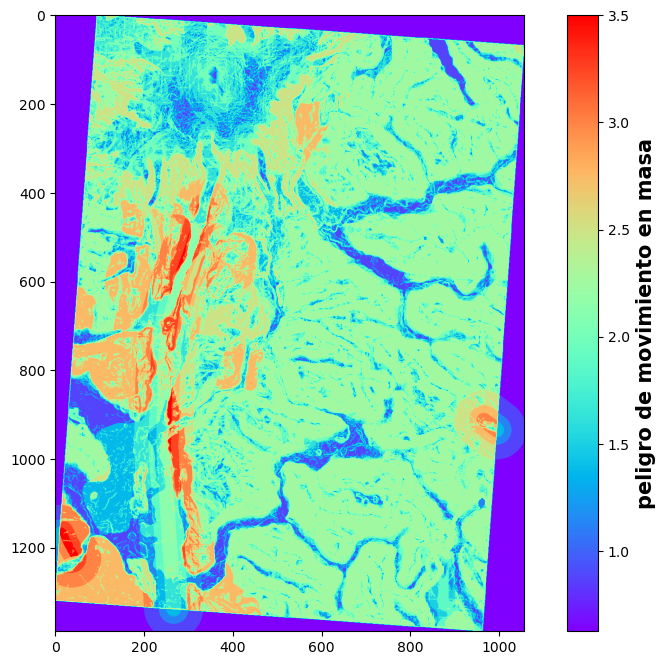

In [ ]:
#Se utiliza la biblioteca rasterio, que funciona en conjunto con numpy, para trabajar con archivos raster y las matrices de datos asociadas a ellos.
falla=rs.open("data/processed/faults_distance_reclass.tif").read(1)#al poner el read(1) solo veremos la banda 1.
geologia=rs.open("data/processed/geology_rasterized.tif").read(1)
pendiente=rs.open("data/processed/slope_reclass.tif").read(1)
#"1.5" es la ponderación de la pendiente, las demás es de 1. todo es dividido en 4 para tener valores de peligro entre 1 y 4.
peligro= ((falla+geologia)+(pendiente*1.5))/4 
#Nueva figura con un tamaño de 14 pulgadas de ancho y 8 pulgadas de alto.
plt.figure(figsize=(14,8))
#Muestra de la imagen
plt.imshow(peligro,cmap="rainbow")
#Establecer valor a los colores de barra.
plt.colorbar(fraction=0.046, pad=0.04).set_label(label='peligro de movimiento en masa', size=15,weight='bold')

### Plot explanatory variables | Graficar variables explicativas

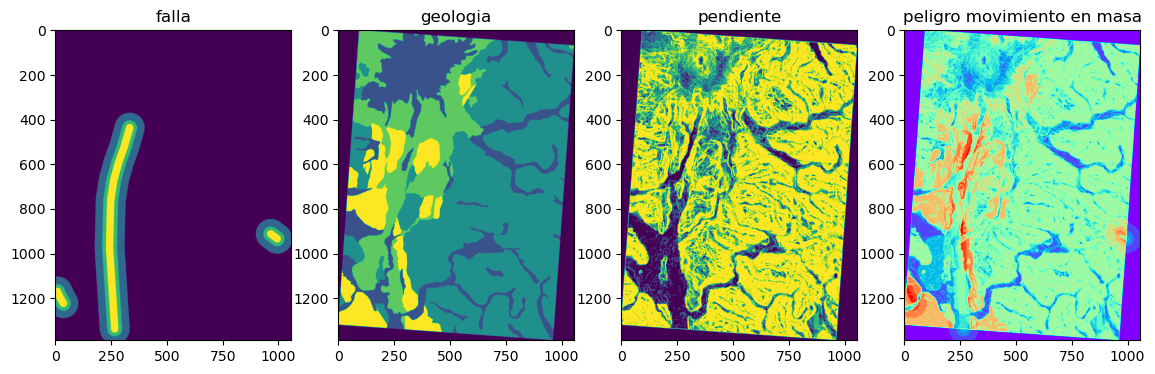

In [ ]:
#Subgráfico "falla".
plt.figure(figsize=(14,14)) #plt.figure(figsize=(x,y))
plt.subplot(141)  #plt.subplot(filas,columnas,figura)
plt.imshow(falla)
plt.title("falla") #título del grafico.
#subgráfico "geologia".
plt.subplot(142)
plt.imshow(geologia)
plt.title("geologia")
#subgráfico "pendiente".
plt.subplot(143)
plt.imshow(pendiente)
plt.title("pendiente")
#subgráfico "peligro".
plt.subplot(144)
plt.imshow(peligro,cmap="rainbow")
plt.title("peligro movimiento en masa");
#Guardando figura en un archivo de imagen en formato PNG.
plt.savefig("images/weighted_overlay_variables.png",dpi=300) #dpi=resolución de impresión en puntos por pulgada.

### Export susceptibility raster | Exportar raster de susceptibilidad

In [ ]:
#Ruta al archivo que creamos.
rspeligro = "outputs/landslide_susceptibility.tif"
#Usaremos el metadata de pendiente para escribir el raster de peligrosidad.
metadata=rs.open("data/processed/slope_reclass.tif").profile
metadata["dtype"] =peligro.dtype #Asigna el tipo de datos (dtype) de la variable "peligro" a la metadata. 
metadata
#Guardando raster con su metadata.
with rs.open(rspeligro,'w',**metadata) as out:
    out.write(peligro,1) #Escribir datos en el archivo de peligrosidad.

### Calculate susceptible area | Calcular superficie susceptible

In [ ]:
rspeligro_numeric = np.array(peligro).astype(float)  #Convertir los valores a tipo float.
suma = np.sum(peligro>= 2.5) #se realiza un filtro de las poderaciones mayores o iguales a 2,5.
resultado = (suma * 900) / 1000000 #Se multiplica la superficie del píxel y se divide por 1000000 para transformar los datos a km².
print(resultado) #Imprimir El resultado del valor calculado en kilómetros cuadrados.

193.7871


### Sample properties | Muestrear propiedades

###### We use the "native:rastersampling" tool (Sample raster values) in QGIS
###### Hacemos uso de la herramienta "native:rastersampling" (Muestra de Valores ráster) en Qgis.

In [ ]:
processing.run("native:rastersampling", {'INPUT':'data/vector/properties.gpkg|layername=Propiedades',
                                         'RASTERCOPY':'C:/Users/bruta/Documents/maletin/UACH/septimo semestre/SIG/practico 8/datos/peligro.tif','COLUMN_PREFIX':'SAMPLE_',
                                         'OUTPUT':'data/processed/properties_susceptibility.gpkg'})

In [ ]:
# # Import GeoPackage file created with "rastersampling" of properties at risk | Importando archivo GeoPackage creado con "rastersampling” de propiedades en peligro.
propiedades=gpd.read_file("data/processed/properties_susceptibility.gpkg")

In [ ]:
## Show the first rows of a DataFrame | Mostrar las primeras filas de un DataFrame.
propiedades.head()

,id,SAMPLE_1,geometry
0,0,2.750,POINT (726818.708 5235898.006)
1,1,2.250,POINT (724755.572 5256345.479)
2,2,2.250,POINT (718668.073 5239377.558)
3,3,0.625,POINT (698731.643 5238635.527)
4,4,1.250,POINT (712159.425 5258352.101)


### Filter high-susceptibility properties | Filtrar propiedades con alta susceptibilidad

In [ ]:
#Apply a filter to the DataFrame to obtain a new DataFrame called "prop_peligro", which only includes properties with a value equal to or greater than 2.5 in column "1"
#Aplica un filtro al DataFrame para obtener un nuevo DataFrame llamado "prop_peligro",el cual únicamente incluye las propiedades que tienen un valor igual o mayor a 2.5 en la columna "1".
prop_peligro= propiedades[propiedades["SAMPLE_1"]>=2.5]

In [ ]:
#Estadísticas descriptivas del DataFrame.
prop_peligro.describe()

,id,SAMPLE_1
count,28.000000,28.000000
mean,67.285714,2.705357
std,40.614591,0.204731
min,0.000000,2.500000
25%,32.250000,2.500000
50%,66.500000,2.750000
75%,96.500000,2.750000
max,146.000000,3.250000
